In [ ]:
import numpy as np
import random
from collections import Counter

1. 读取数据集

In [ ]:
########读取机器学习数据集的示例代码 (LIBSVM格式)
def load_svmfile(filename):
    X = []
    Y = []
    with open(filename, 'r') as f:
        filelines = f.readlines()
        for fileline in filelines:
            fileline = fileline.strip().split(' ')
            #print(fileline)
            Y.append(int(fileline[0]))
            tmp = []
            for t in fileline[1:]:
                if len(t)==0:
                    continue
                tmp.append(float(t.split(':')[1]))
            X.append(tmp)
    
    return np.array(X), np.array(Y)

In [ ]:
# https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary.html#svmguide1
########读取数据集
dataset = 'svmguide1'
print('Start loading dataset {}'.format(dataset))
X, Y = load_svmfile("data/"+dataset) # train set
X_test, Y_test = load_svmfile("data/"+'{}.t'.format(dataset)) # test set
print('trainset X shape {}, train label Y shape {}'.format(X.shape, Y.shape))
print('testset X_test shape {}, test label Y shape {}'.format(X_test.shape,Y_test.shape))

2. 训练和验证集的划分

In [ ]:
######### 将原来的训练集划分成两部分：训练和验证
random.seed(777777) #定下随机种子
N = X.shape[0] 
valid_frac = 0.2 # 设置验证集的比例为20%
valid_size = int(N*valid_frac)

# 出于简单起见，这里直接使用random shuffle来划分
shuffle_index = [i for i in range(N)]
random.shuffle(shuffle_index)
valid_index, train_index = shuffle_index[:valid_size], shuffle_index[valid_size:]
X_valid, Y_valid = X[valid_index], Y[valid_index]
X_train, Y_train = X[train_index], Y[train_index]
print('trainset X_train shape {}, validset X_valid shape {}'.format(X_train.shape, X_valid.shape))

3. 实现一个KNN 分类器

In [ ]:
########实现一个KNN分类器的模型，需要完成的功能包括train, test和_calculate_distances三部分
class KNN_model():
    def __init__(self, k=1):
        self.k = k
    
    def train(self, x_train, y_train):
        """Implement the training code for KNN
        Input: 
            x_train: Training instances of size (N, D), where N denotes the number of instances and D denotes the feature dimension
            y_train: Training labels of size (N, )
        """
        # TODO:lazy training
        self.x_train = x_train
        self.y_train = y_train
        
    def test(self, x_test):
        """
        Input: Test instances of size (N, D), where N denotes the number of instances and D denotes the feature dimension
        Return: Predicted labels of size (N, )
        """
        # TODO
        result = []
        for i in range(x_test.shape[0]):
            dist = self._calculate_distances(x_test[i])
            index = np.argsort(dist)
            index = index[:self.k]
            labels = [self.y_train[j] for j in index]
            counter = Counter(labels)
            result.append(counter.most_common(1)[0][0])
        return result
            

    def _calculate_distances(self, point):
        """Calculate the euclidean distance between a test instance and all points in the training set x_train
        Input: a single point of size (D, )
        Return: distance matrix of size (N, )
        """
        # TODO
        dist = []
        for i in range(self.x_train.shape[0]):
            temp = 0
            for j in range(self.x_train.shape[1]):
                temp += (point[j] - self.x_train[i][j]) ** 2
            dist.append(temp ** 0.5)
        return dist
        

4. 实现评估指标-准确率的计算

In [ ]:
######### 这里需要实现计算准确率的函数，注意我们期望的输出是百分制，如准确率是0.95，我们期望的输出是95
def cal_accuracy(y_pred, y_gt):
    '''
    y_pred: predicted labels (N,)
    y_gt: ground truth labels (N,)
    Return: Accuracy (%)
    '''
    assert len(y_pred) == len(y_gt), "The length of predicted labels and ground truth labels must be the same."
    # TODO
    count = 0
    for i in range(len(y_pred)):
        if(y_pred[i] == y_gt[i]):
            count += 1
    return count * 100 / len(y_pred)
assert abs(cal_accuracy(np.zeros(Y.shape[0]), Y)-100*1089.0/3089.0)<1e-3

5. 根据验证集进行超参数选择

k=1, accuracy on validation=96.27228525121556%
k=3, accuracy on validation=96.27228525121556%
k=5, accuracy on validation=96.27228525121556%
k=7, accuracy on validation=96.43435980551054%
k=9, accuracy on validation=96.11021069692059%
k=11, accuracy on validation=95.62398703403565%


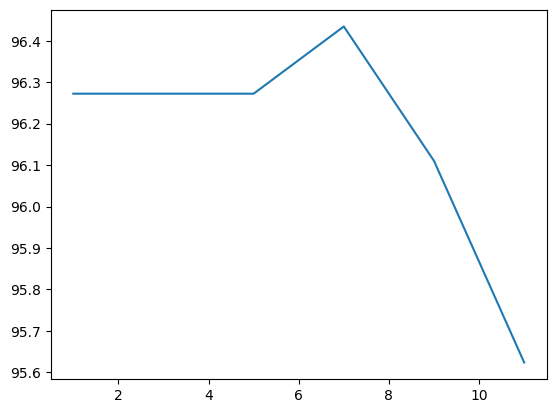

In [7]:
#####使用验证集来选择超参数
possible_k_list = [1,3,5,7,9,11] # 在本次实验中候选的超参数取值
accs = [] # 将每个取值k对应的验证集准确率加入列表
for k in possible_k_list:
    # TODO:模型的超参数设置为k
    model = KNN_model(k)
    # TODO:在训练集上训练, 提示: model.train()
    model.train(X_train, Y_train)
    # TODO:在验证集X_valid上给出预测结果 Y_pred_valid, 提示：model.test()
    Y_pred_valid =  model.test(X_valid)
    #计算验证集上的准确率
    acc_k = cal_accuracy(Y_pred_valid, Y_valid)
    #将每个取值k对应的验证集准确率加入列表
    accs.append(acc_k)
    print('k={}, accuracy on validation={}%'.format(k, acc_k))

import matplotlib.pyplot as plt
plt.plot(possible_k_list, accs) #画出每个k对应的验证集准确率

In [8]:
####### 基于上面的结果确定验证集上的最好的超参数k，根据这个k最终在测试集上进行测试
# TODO:定义最好的k对应的模型
model = KNN_model(7)
# TODO:在训练集上训练，注意这里可以使用全部的训练数据
model.train(X, Y)
# TODO:在测试集上测试生成预测 Y_pred_test
Y_pred_test = model.test(X_test)
print('Test Accuracy={}%'.format(cal_accuracy(Y_pred_test, Y_test)))

6.实现5折交叉验证并进行超参数选择

In [9]:
#####以下需要实现5折交叉验证，可以参考之前训练集和验证集划分的方式
folds = 5
accs=[]

shuffle_index = [i for i in range(N)]
random.shuffle(shuffle_index)
fold_index = np.array_split(shuffle_index, folds)

for k in possible_k_list: # 遍历所有可能的k
    print('******k={}******'.format(k))
    valid_accs = []
    for i in range(folds): # 第i折的实验
        # TODO: 生成第i折的训练集 X_train_i, Y_train_i和验证集 X_valid_i, Y_valid_i; 提示：可参考之前random shuffle的方式来生成index
        valid_index = fold_index[i]
        train_index = np.hstack([fold_index[j] for j in range(folds) if j != i])
        
        X_train_i = X[train_index]
        Y_train_i = Y[train_index]
        X_valid_i = X[valid_index]
        Y_valid_i = Y[valid_index]
        # TODO: 定义超参数设置为k的模型
        model = KNN_model(k)
        model = KNN_model(k)
        # TODO: 在Fold-i上进行训练
        model.train(X_train_i, Y_train_i)
        model.train(X_train_i, Y_train_i)
        # TODO: 给出Fold-i验证集X_valid_i上的预测结果 Y_pred_valid_i
        Y_pred_valid_i = model.test(X_valid_i)
        Y_pred_valid_i = model.test(X_valid_i)
        acc = cal_accuracy(Y_pred_valid_i, Y_valid_i)
        valid_accs.append(acc)
        print('Valid Accuracy on Fold-{}: {}%'.format(i+1, acc))
    
    print('k={}, Accuracy {}+-{}%'.format(k, np.mean(valid_accs), np.std(valid_accs)))

******k=1******
Valid Accuracy on Fold-1: 94.8220064724919%
Valid Accuracy on Fold-2: 95.63106796116504%
Valid Accuracy on Fold-3: 95.79288025889967%
Valid Accuracy on Fold-4: 94.8220064724919%
Valid Accuracy on Fold-5: 96.59643435980551%
k=1, Accuracy 95.53287910497082+-0.6661938502908226%
******k=3******
Valid Accuracy on Fold-1: 96.92556634304208%
Valid Accuracy on Fold-2: 96.92556634304208%
Valid Accuracy on Fold-3: 95.63106796116504%
Valid Accuracy on Fold-4: 96.60194174757281%
Valid Accuracy on Fold-5: 97.08265802269044%
k=3, Accuracy 96.6333600835025+-0.5250169987189106%
******k=5******
Valid Accuracy on Fold-1: 96.60194174757281%
Valid Accuracy on Fold-2: 96.60194174757281%
Valid Accuracy on Fold-3: 95.9546925566343%
Valid Accuracy on Fold-4: 96.27831715210355%
Valid Accuracy on Fold-5: 97.40680713128039%
k=5, Accuracy 96.56874006703278+-0.48289976639061016%
******k=7******
Valid Accuracy on Fold-1: 96.60194174757281%
Valid Accuracy on Fold-2: 97.0873786407767%
Valid Accuracy o

7.最终确定超参数之后，完成在测试集上的测试

In [10]:
#####基于交叉验证确定验证集上的最好的超参数k，根据这个k最终在测试集上进行测试
# TODO:定义最好的k对应的模型
model = KNN_model(9)
model = KNN_model(9)
# TODO:在训练集上训练，注意这里可以使用全部的训练数据
model.train(X, Y)
model.train(X, Y)
# TODO:在测试集上测试生成预测 Y_pred_test
Y_pred_test = model.test(X_test)
Y_pred_test = model.test(X_test)
print('Test Accuracy chosing k using cross-validation={}%'.format(cal_accuracy(Y_pred_test, Y_test)))

Test Accuracy chosing k using cross-validation=96.6%


8.针对不均衡数据集，实现precision, recall 和F1 score 的计算

In [11]:
best_k = 9
#####如果训练/测试集不均衡如何评估模型呢？
#####生成一个不均衡的测试集，由于示例数据集中所有的标签1都在后面所以出于方便直接这样来生成一个不均衡的测试集
N_test = int(X_test.shape[0]*0.7)
X_test, Y_test = X_test[:N_test], Y_test[:N_test]
print(Counter(Y_test)) # 输出新的测试集中的标签分布
model = KNN_model(k=9) # 此处请填入交叉验证确定的最好的k
model.train(X, Y)
Y_pred_test = model.test(X_test)

from sklearn.metrics import precision_score, recall_score, f1_score
#实现计算percision， recall和F1 score的函数
def cal_prec_recall_f1(Y_pred, Y_gt):
    '''
    Input: predicted labels y_pred, ground truth labels Y_gt
    Retur: precision, recall, and F1 score
    '''
    # TODO:
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    
    for i in range(len(Y_pred)):
        if Y_pred[i] == Y_gt[i]:
            if Y_pred[i] == 1:
                tp += 1
            else:
                tn += 1
        else:
            if Y_pred[i] == 1:
                fp += 1
            else:
                fn += 1
        
    if tp + fp == 0:
        precision = 0
    else:
        precision = tp / (tp + fp)
        
    if tp + fn == 0:
        recall = 0
    else:
        recall = tp / (tp + fn)
        
    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * precision * recall / (precision + recall)  
    
    return precision, recall, f1
print(cal_prec_recall_f1(Y_pred_test, Y_test))


Counter({np.int64(0): 2000, np.int64(1): 800})
(0.9142857142857143, 0.96, 0.9365853658536586)
